# Notebook for Fitting PDFs with diffpy.cmi

## Import Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from diffpy_fitting import (
    FitConfig, fit_one, fit_batch, results_to_dataframe, plot_series,
    build_reference, fit_dgr_batch,
    PhaseConfig, MultiPhaseFitConfig, fit_one_multiphase, fit_batch_multiphase,
)

%matplotlib widget

## Set Path

In [190]:
file_path = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO_18keV\BTO400nmS3_280K70powsurv1\output") 

# Short Range Fitting

## Config Variables

In [191]:
cfg = FitConfig(

    # SHORT RANGE FITTING CONFIGURATION

    # ── Required ──────────────────────────────────────────────
    cif_path = f"{file_path}/BaTiO3_tetragonal.cif",   # path to your CIF file

    # ── PDF r-range ───────────────────────────────────────────
    rmin  = 1.5,   # Å  — lower bound of fit range
    rmax  = 10.0,   # Å  — upper bound of fit range
    rstep = 0.01,   # Å  — grid spacing

    # ── Structure ─────────────────────────────────────────────
    space_group = "P4mm",   # space group for constrainAsSpaceGroup

    # ── Parameter bounds for least_squares ───────────────────
    param_bounds = {
        "s1":           (1e-4, 10.0),
        "Delta2":       (0.0,  50.0),
        "Calib_Qdamp":  (0.0,  0.15),
        "Calib_Qbroad": (0.0,  0.10),
        "a":            (3.9, 4.3),
        "c":            (3.9, 4.3),
        "_adp_default": (1e-5, 0.05),  # applies to all ADP_ and Uiso_ parameters
    },

    # ── Element-level ADP grouping ────────────────────────────
    # Ties all ADP components (U11, U33, …) for each element to a single
    # shared Uiso. Use None to fit freely, or a float to fix to that value.
    # Results appear as 'Uiso_Ba', 'Uiso_Ti', 'Uiso_O' in result.params.
    element_uiso = {
        "Ba": None,    # fit one shared Uiso_Ba for all Ba sites
        "Ti": None,    # fit one shared Uiso_Ti for all Ti sites
        "O":  None,    # fit one shared Uiso_O  for all O  sites
    },
    # To fix an element instead of fitting it:
    # element_uiso = {"Ba": None, "Ti": None, "O": 0.006},
    # To use per-component ADPs (old behavior), leave element_uiso = {}


    # 18 keV config
    # ── Q-range ───────────────────────────────────────────────
    qmax = 9.0,    # Å⁻¹ — max Q used in PDF calculation
    qmin = 0.3,     # Å⁻¹ — min Q used in PDF calculation

    # ── Initial parameter guesses ─────────────────────────────
    scale_i  = 0.5,    # overall scale factor
    uiso_i   = 0.005,  # Å²  — starting Uiso for all sites
    delta2_i = 1.7,    # Å²  — correlated motion parameter
    qdamp_i  = 0.01,   # Å⁻¹ — instrumental dampening
    qbroad_i = 0.008,   # Å⁻¹ — instrumental broadening

    # # 31.2 keV config
    # # ── Q-range ───────────────────────────────────────────────
    # qmax = 12.0,    # Å⁻¹ — max Q used in PDF calculation
    # qmin = 0.3,     # Å⁻¹ — min Q used in PDF calculation

    # # ── Initial parameter guesses ─────────────────────────────
    # scale_i  = 0.5,    # overall scale factor
    # uiso_i   = 0.005,  # Å²  — starting Uiso for all sites
    # delta2_i = 1.7,    # Å²  — correlated motion parameter
    # qdamp_i  = 0.03,   # Å⁻¹ — instrumental dampening
    # qbroad_i = 0.06,   # Å⁻¹ — instrumental broadening

    # ── Instrumental toggles ──────────────────────────────────
    fix_qdamp  = True,   # True = pin Qdamp even in full fits
    fix_qbroad = True,   # True = pin Qbroad even in full fits

    # ── Reduced-mode pinning ──────────────────────────────────
    pinned_in_reduced = ["Delta2", "Calib_Qdamp", "Calib_Qbroad"],

    # ── Output ────────────────────────────────────────────────
    save_outputs = False,    # False = no files written (good for exploring)
    resdir = None,          # Path to save .res files; defaults to data_dir/res
    fitdir = None,          # Path to save .fit files; defaults to data_dir/fit
    figdir = None,          # Path to save figures;   defaults to data_dir/fig

    # ── Performance ───────────────────────────────────────────
    run_parallel = True,    # use multiprocessing for PDF calculation
)

## Fit One File

Fitting BaTiO3_-80.0_gr.gr [full]
    scale          Rw = 0.5525
    + lat          Rw = 0.3932
    + adp          Rw = 0.2461
    + Delta2       Rw = 0.2451
    final polish   Rw = 0.2451


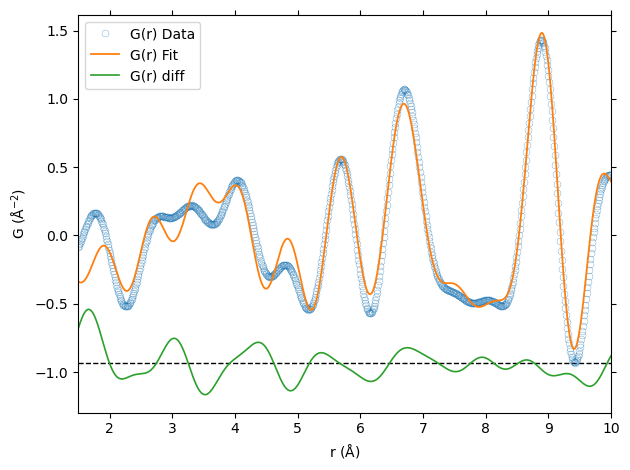

In [192]:
result = fit_one(f"{file_path}/BaTiO3_-80.0_gr.gr", cfg)
result.plot()

In [5]:
result.params

{'s1': np.float64(0.18790802694959371),
 'a': 3.97969718799561,
 'c': 4.102818565032855,
 'Uiso_Ba': np.float64(0.01),
 'Uiso_Ti': np.float64(0.008),
 'Uiso_O': np.float64(0.012),
 'Delta2': 1.4901161065606916e-08,
 'Calib_Qdamp': 0.01,
 'Calib_Qbroad': 0.008}

## Batch Fit

Found 5 file(s): 2 full, 3 reduced.

=== Pass 1: Full-mode refinements ===
  [1/5] BaTiO3_-80.0_gr.gr... 

Rw = 0.2451  t=-80.0 ns
  [2/5] BaTiO3_-5.0_gr.gr... Rw = 0.2443  t=-5.0 ns

Reference values (averaged over full fits):
  Delta2         = 2.636835
  Calib_Qdamp    = 0.010000
  Calib_Qbroad   = 0.008000

=== Pass 2: Reduced-mode refinements ===
  [3/5] BaTiO3_0.7_gr.gr... Rw = 0.2461  t=0.7 ns
  [4/5] BaTiO3_12.450000000000001_gr.gr... Rw = 0.2445  t=12.450000000000001 ns
  [5/5] BaTiO3_1146.0_gr.gr... Rw = 0.2411  t=1146.0 ns


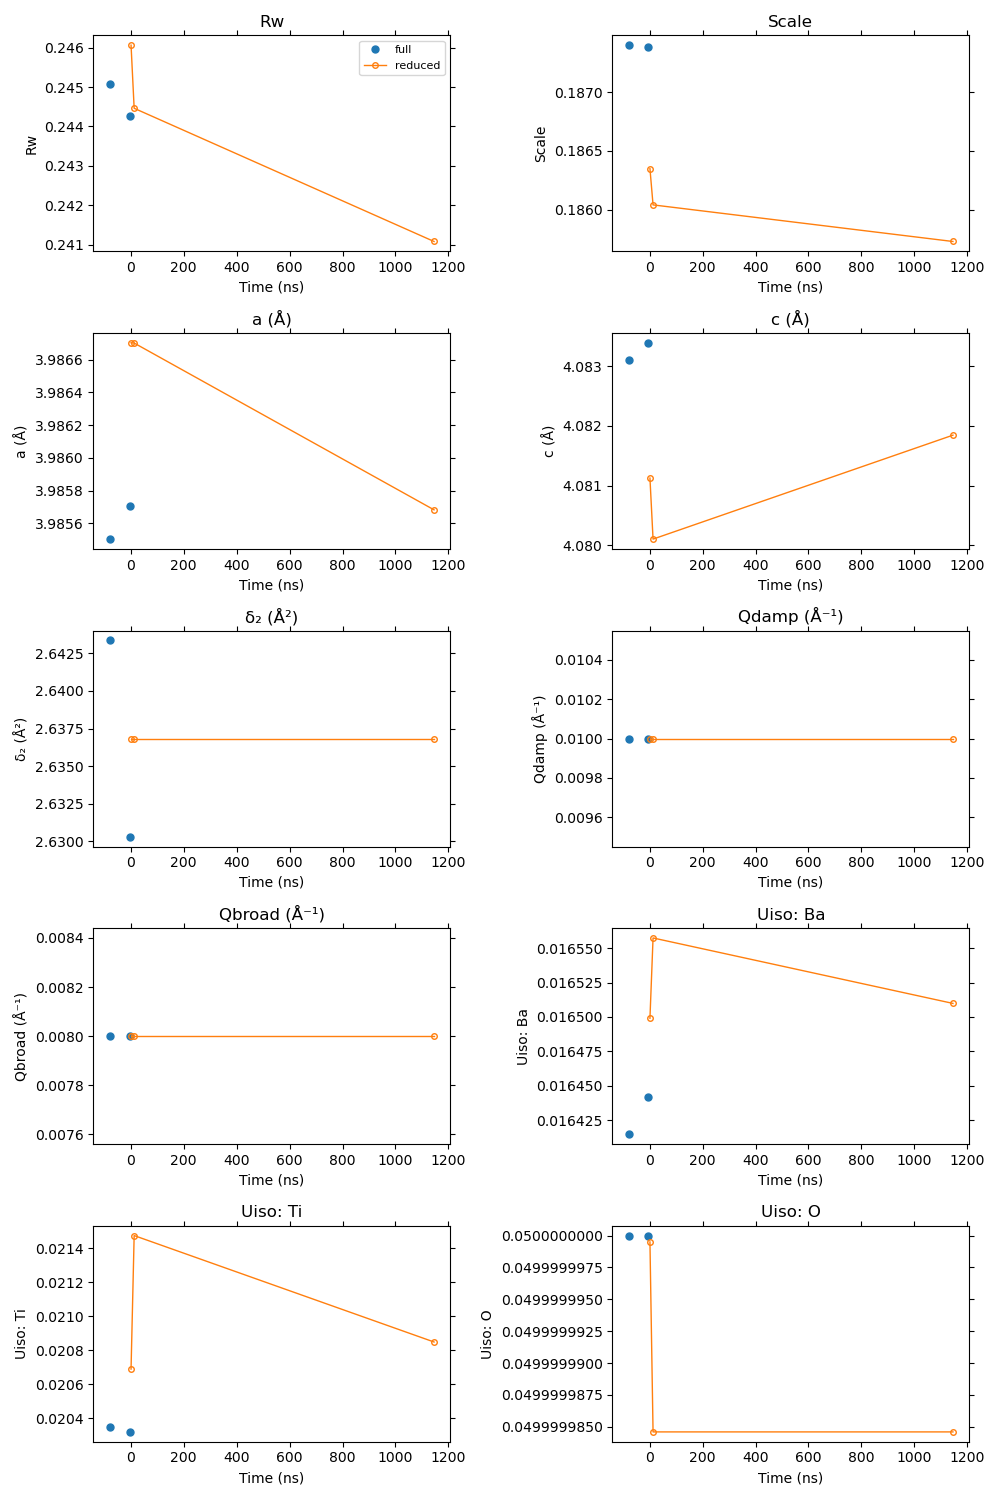

In [193]:
results = fit_batch(f"{file_path}/BaTiO3_*.gr", cfg, full_indices=(0, 2))
df = results_to_dataframe(results)
plot_series(df);

# Long Range Fitting

## Config Variables

In [194]:
cfg = FitConfig(

    # LONG RANGE FITTING CONFIGURATION

    # ── Required ──────────────────────────────────────────────
    # cif_path = f"{file_path}/BaTiO3_cubic.cif",   # path to your CIF file
    cif_path = f"{file_path}/BaTiO3_tetragonal.cif",   # path to your CIF file

    # ── PDF r-range ───────────────────────────────────────────
    rmin  = 10.0,   # Å  — lower bound of fit range
    rmax  = 30.0,   # Å  — upper bound of fit range
    rstep = 0.01,   # Å  — grid spacing

    # ── Structure ─────────────────────────────────────────────
    # space_group = "Pm-3m",   # space group for constrainAsSpaceGroup
    space_group = "P4mm",   # space group for constrainAsSpaceGroup

    # ── Parameter bounds for least_squares ───────────────────
    param_bounds = {
        "s1":           (1e-4, 10.0),
        "Delta2":       (0.0,  50.0),
        "Calib_Qdamp":  (0.0,  0.15),
        "Calib_Qbroad": (0.0,  0.10),
        "a":            (3.9, 4.3),
        "c":            (3.9, 4.3),
        "_adp_default": (1e-5, 0.05),  # applies to all ADP_ and Uiso_ parameters
    },

    # ── Element-level ADP grouping ────────────────────────────
    # Ties all ADP components (U11, U33, …) for each element to a single
    # shared Uiso. Use None to fit freely, or a float to fix to that value.
    # Results appear as 'Uiso_Ba', 'Uiso_Ti', 'Uiso_O' in result.params.
    element_uiso = {
        "Ba": None,    # fit one shared Uiso_Ba for all Ba sites
        "Ti": None,    # fit one shared Uiso_Ti for all Ti sites
        "O":  None,    # fit one shared Uiso_O  for all O  sites
    },
    # To fix an element instead of fitting it:
    # element_uiso = {"Ba": None, "Ti": None, "O": 0.006},
    # To use per-component ADPs (old behavior), leave element_uiso = {}


    # 18 keV config
    # ── Q-range ───────────────────────────────────────────────
    qmax = 9.0,    # Å⁻¹ — max Q used in PDF calculation
    qmin = 0.3,     # Å⁻¹ — min Q used in PDF calculation

    # ── Initial parameter guesses ─────────────────────────────
    scale_i  = 0.5,    # overall scale factor
    uiso_i   = 0.005,  # Å²  — starting Uiso for all sites
    delta2_i = 1.7,    # Å²  — correlated motion parameter
    qdamp_i  = 0.01,   # Å⁻¹ — instrumental dampening
    qbroad_i = 0.05,   # Å⁻¹ — instrumental broadening

    # # 31.2 keV config
    # # ── Q-range ───────────────────────────────────────────────
    # qmax = 12.0,    # Å⁻¹ — max Q used in PDF calculation
    # qmin = 0.3,     # Å⁻¹ — min Q used in PDF calculation

    # # ── Initial parameter guesses ─────────────────────────────
    # scale_i  = 0.5,    # overall scale factor
    # uiso_i   = 0.005,  # Å²  — starting Uiso for all sites
    # delta2_i = 1.7,    # Å²  — correlated motion parameter
    # qdamp_i  = 0.03,   # Å⁻¹ — instrumental dampening
    # qbroad_i = 0.06,   # Å⁻¹ — instrumental broadening

    # ── Instrumental toggles ──────────────────────────────────
    fix_qdamp  = True,   # True = pin Qdamp even in full fits
    fix_qbroad = True,   # True = pin Qbroad even in full fits

    # ── Reduced-mode pinning ──────────────────────────────────
    pinned_in_reduced = ["Delta2", "Calib_Qdamp", "Calib_Qbroad"],

    # ── Output ────────────────────────────────────────────────
    save_outputs = False,    # False = no files written (good for exploring)
    resdir = None,          # Path to save .res files; defaults to data_dir/res
    fitdir = None,          # Path to save .fit files; defaults to data_dir/fit
    figdir = None,          # Path to save figures;   defaults to data_dir/fig

    # ── Performance ───────────────────────────────────────────
    run_parallel = True,    # use multiprocessing for PDF calculation
)

## Fit One File

Fitting BaTiO3_-80.0_gr.gr [full]
    scale          Rw = 0.7653
    + lat          Rw = 0.2393
    + adp          Rw = 0.1485
    + Delta2       Rw = 0.1474
    final polish   Rw = 0.1474


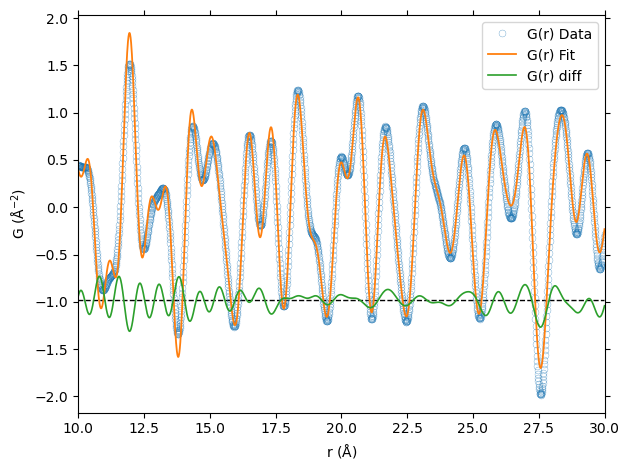

In [195]:
result = fit_one(f"{file_path}/BaTiO3_-80.0_gr.gr", cfg)
result.plot()

In [27]:
result.params

{'s1': np.float64(0.21245645628900667),
 'a': 4.0114411884840475,
 'c': 4.014311247376941,
 'Uiso_Ba': np.float64(0.0067709276986846175),
 'Uiso_Ti': np.float64(0.01579315247652301),
 'Uiso_O': np.float64(0.018611801895558465),
 'Delta2': 7.896647463432605e-07,
 'Calib_Qdamp': 0.01,
 'Calib_Qbroad': 0.05}

## Batch Fit

Found 5 file(s): 2 full, 3 reduced.

=== Pass 1: Full-mode refinements ===
  [1/5] BaTiO3_-80.0_gr.gr... Rw = 0.1474  t=-80.0 ns
  [2/5] BaTiO3_-5.0_gr.gr... Rw = 0.1474  t=-5.0 ns

Reference values (averaged over full fits):
  Delta2         = 0.000000
  Calib_Qdamp    = 0.010000
  Calib_Qbroad   = 0.050000

=== Pass 2: Reduced-mode refinements ===
  [3/5] BaTiO3_0.7_gr.gr... Rw = 0.1479  t=0.7 ns
  [4/5] BaTiO3_12.450000000000001_gr.gr... Rw = 0.1482  t=12.450000000000001 ns
  [5/5] BaTiO3_1146.0_gr.gr... Rw = 0.1478  t=1146.0 ns


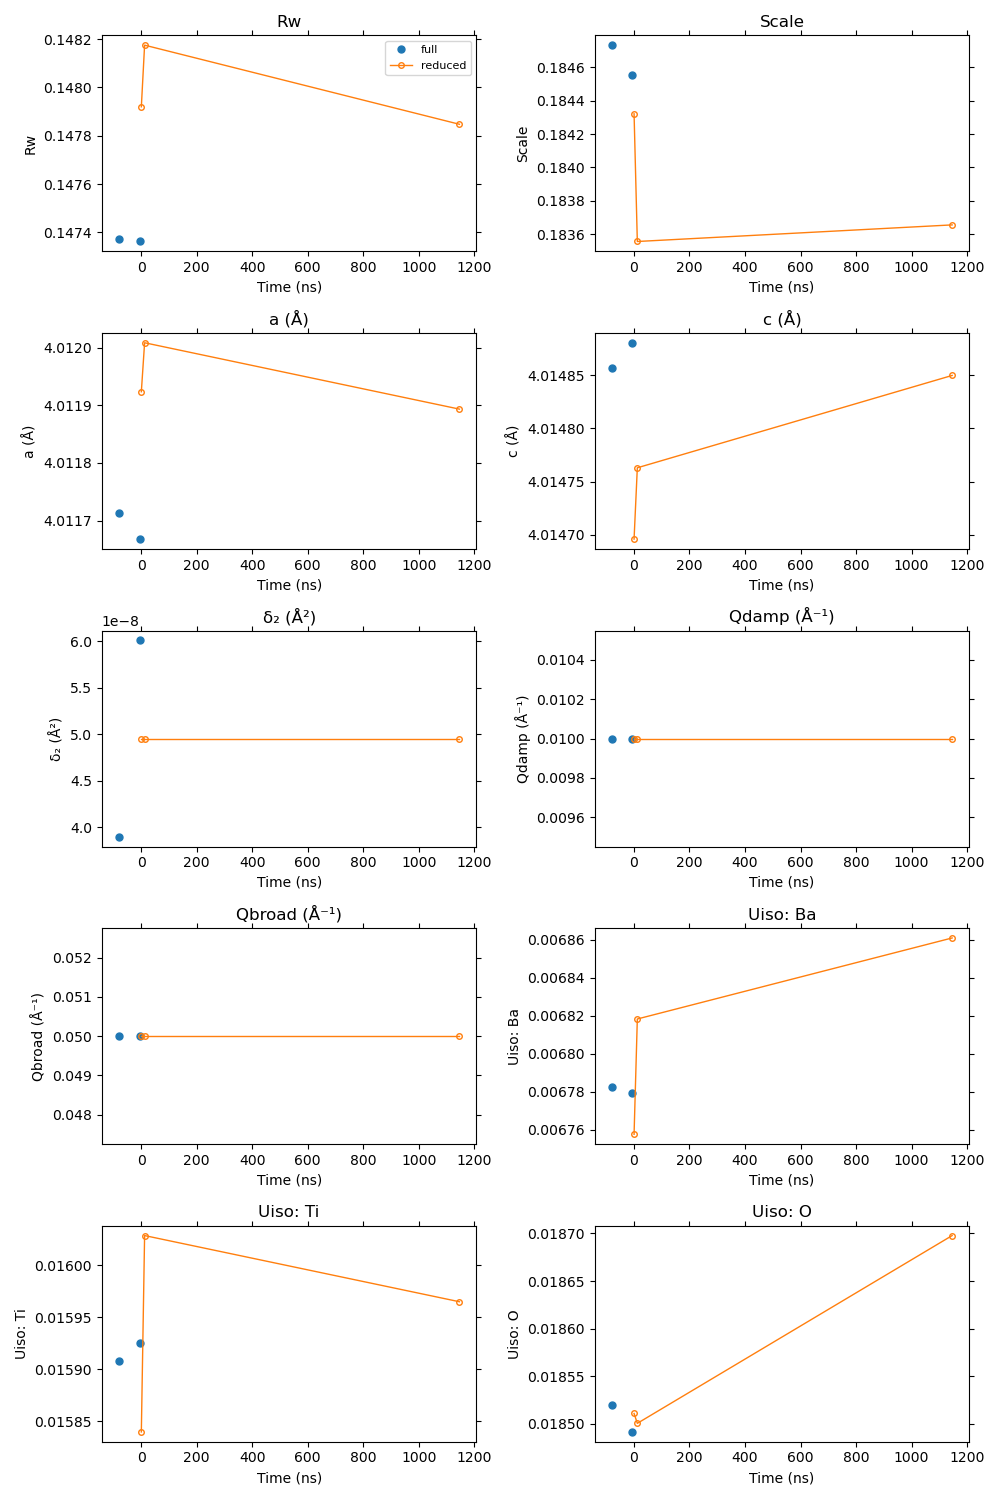

In [196]:
results = fit_batch(f"{file_path}/BaTiO3_*.gr", cfg, full_indices=(0, 2))
df = results_to_dataframe(results)
plot_series(df);

## Fitting dG(r)s

Building reference from 3 file(s):
  BaTiO3_-80.0_gr.gr
  BaTiO3_-10.0_gr.gr
  BaTiO3_-5.0_gr.gr
Full-fitting averaged reference G(r)...
Fitting tmp7g6820ad.gr [full]
    scale          Rw = 0.7195
    + lat          Rw = 0.3417
    + adp          Rw = 0.0819
    + Delta2       Rw = 0.0818
    final polish   Rw = 0.0818
  Reference Rw = 0.0818
Excluded 3 reference file(s) from batch.

=== ΔG fits: 37 file(s) ===
  [1/37] BaTiO3_0.2_gr.gr... 

c:\Users\lheald\AppData\Local\miniconda3\envs\diffpy\Lib\site-packages\diffpy\srfit\fitbase\fitresults.py:205: RuntimeWarning: divide by zero encountered in divide
  self.cov = numpy.dot(vh.T.conj() / s**2, vh)
c:\Users\lheald\AppData\Local\miniconda3\envs\diffpy\Lib\site-packages\diffpy\srfit\fitbase\fitresults.py:205: RuntimeWarning: invalid value encountered in divide
  self.cov = numpy.dot(vh.T.conj() / s**2, vh)
c:\Users\lheald\AppData\Local\miniconda3\envs\diffpy\Lib\site-packages\diffpy\srfit\fitbase\fitresults.py:205: RuntimeWarning: invalid value encountered in dot
  self.cov = numpy.dot(vh.T.conj() / s**2, vh)
c:\Users\lheald\AppData\Local\miniconda3\envs\diffpy\Lib\site-packages\diffpy\srfit\fitbase\fitresults.py:317: RuntimeWarning: invalid value encountered in multiply
  u = dci * vu


Rw = 0.8581  t=0.2 ns
  [2/37] BaTiO3_0.3_gr.gr... Rw = 0.9257  t=0.3 ns
  [3/37] BaTiO3_0.4_gr.gr... Rw = 0.6424  t=0.4 ns
  [4/37] BaTiO3_0.5_gr.gr... Rw = 0.9024  t=0.5 ns
  [5/37] BaTiO3_0.6_gr.gr... Rw = 0.8242  t=0.6 ns
  [6/37] BaTiO3_0.7_gr.gr... Rw = 0.7893  t=0.7 ns
  [7/37] BaTiO3_0.8_gr.gr... Rw = 0.7655  t=0.8 ns
  [8/37] BaTiO3_0.9_gr.gr... Rw = 0.7594  t=0.9 ns
  [9/37] BaTiO3_1.05_gr.gr... Rw = 0.7200  t=1.05 ns
  [10/37] BaTiO3_1.25_gr.gr... Rw = 0.7071  t=1.25 ns
  [11/37] BaTiO3_1.55_gr.gr... Rw = 0.6697  t=1.55 ns
  [12/37] BaTiO3_2.41_gr.gr... Rw = 0.5578  t=2.41 ns
  [13/37] BaTiO3_3.63_gr.gr... Rw = 0.6413  t=3.63 ns
  [14/37] BaTiO3_5.470000000000001_gr.gr... Rw = 0.6684  t=5.470000000000001 ns
  [15/37] BaTiO3_8.26_gr.gr... Rw = 0.5396  t=8.26 ns
  [16/37] BaTiO3_12.450000000000001_gr.gr... Rw = 0.6050  t=12.450000000000001 ns
  [17/37] BaTiO3_18.790000000000003_gr.gr... Rw = 0.5912  t=18.790000000000003 ns
  [18/37] BaTiO3_28.34_gr.gr... Rw = 0.5803  t=28.34 n

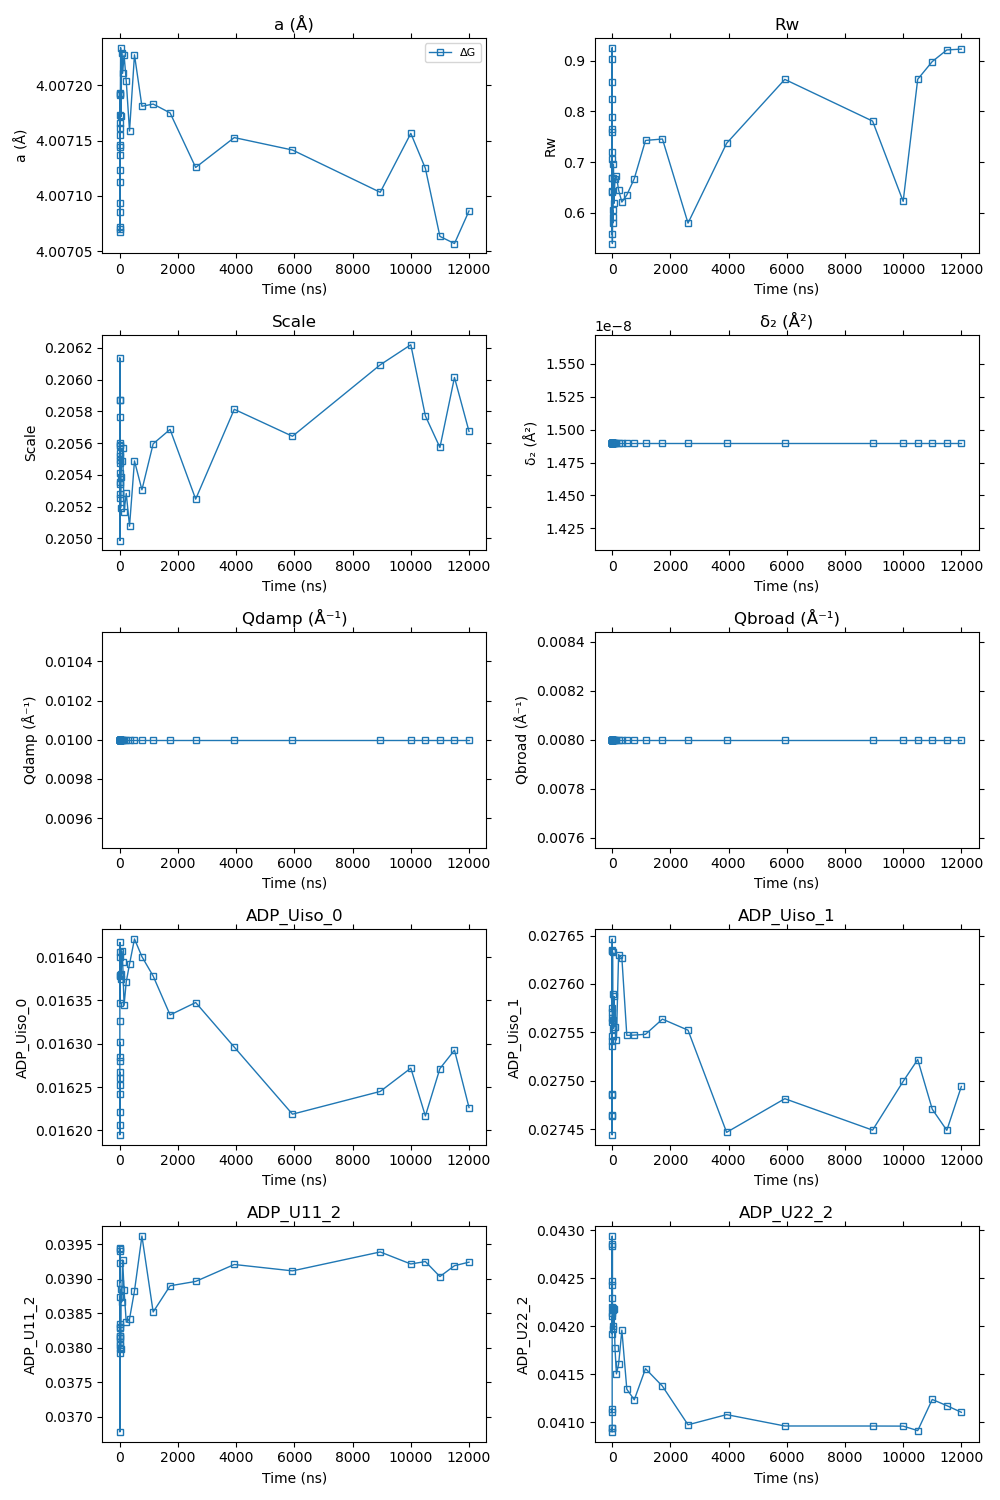

In [5]:
# Build reference from pre-t0 files (averages them, fits the average once)
ref = build_reference([f"{file_path}/BaTiO3_-80.0_gr.gr", f"{file_path}/BaTiO3_-10.0_gr.gr", f"{file_path}/BaTiO3_-5.0_gr.gr"], cfg)

# Fit ΔG for the full time series
results = fit_dgr_batch(f"{file_path}/BaTiO3_*.gr", ref, cfg, pin_scale=False)

df = results_to_dataframe(results)
plot_series(df);

In [13]:
df

,file,rw,mode,s1,a,c,ADP_U11_0,ADP_U33_0,ADP_U11_1,ADP_U33_1,ADP_U11_2,ADP_U33_2,ADP_U11_3,ADP_U22_3,ADP_U33_3,Delta2,Calib_Qdamp,Calib_Qbroad
0,BaTiO3_1.0_gr.gr,0.601820,dgr,0.635488,4.009536,4.033614,0.006238,0.009156,0.006330,0.022997,0.099223,0.1,0.006409,0.006409,0.006409,0.000004,0.04,0.07
1,BaTiO3_10.0_gr.gr,0.463074,dgr,0.635488,4.009744,4.033416,0.006198,0.009239,0.006406,0.022861,0.099220,0.1,0.006402,0.006402,0.006402,0.000004,0.04,0.07
2,BaTiO3_200.0_gr.gr,0.545616,dgr,0.635488,4.009525,4.033590,0.006253,0.009105,0.006445,0.022651,0.099238,0.1,0.006410,0.006410,0.006410,0.000004,0.04,0.07


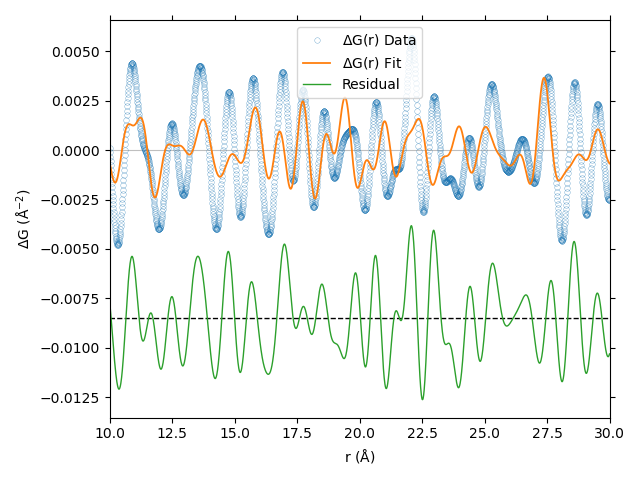

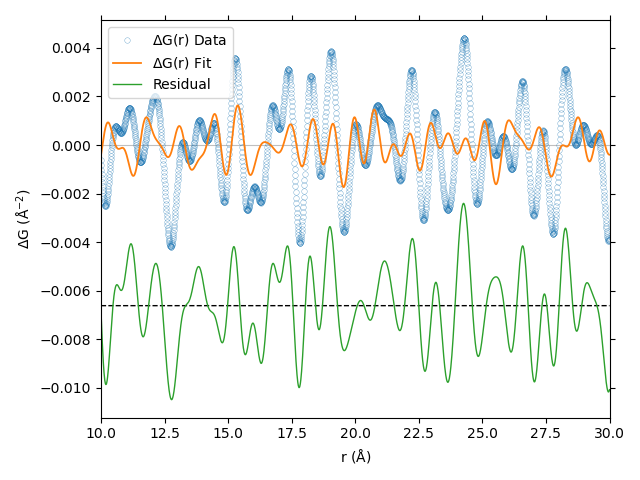

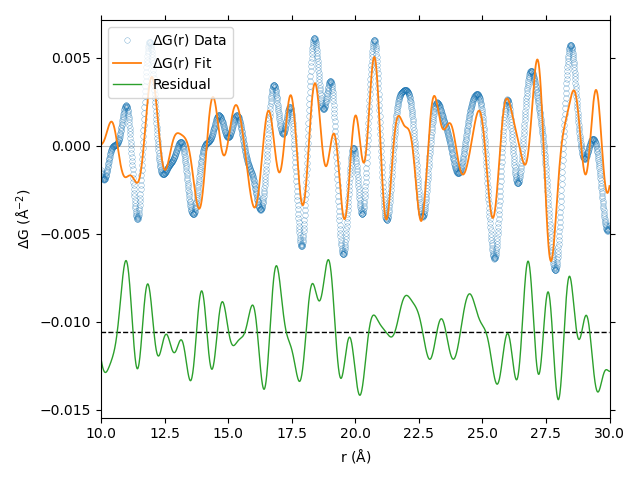

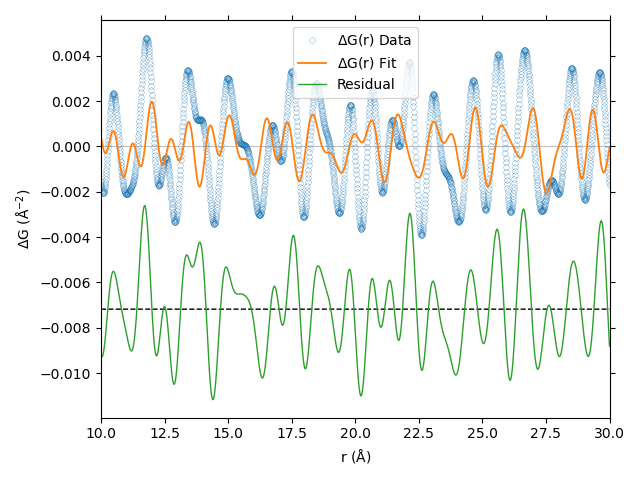

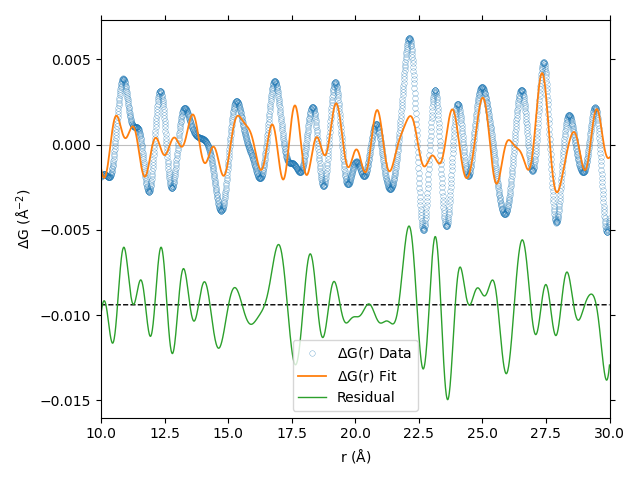

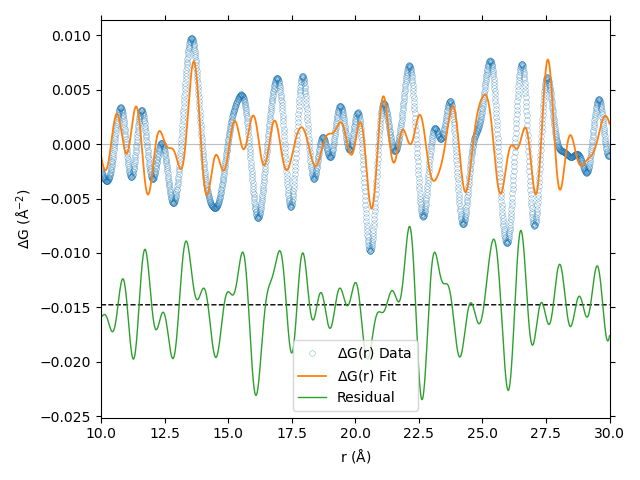

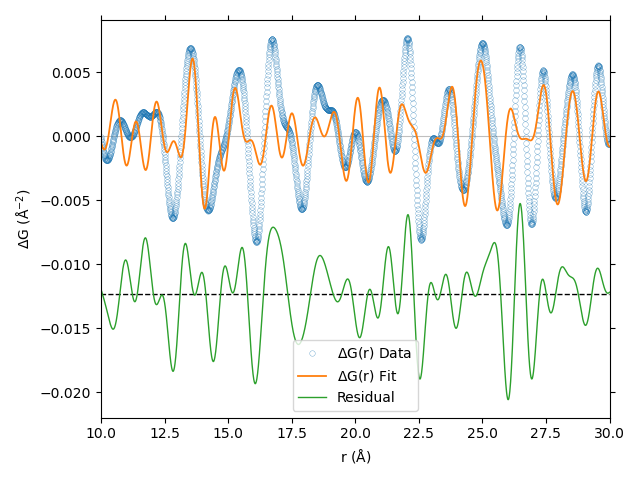

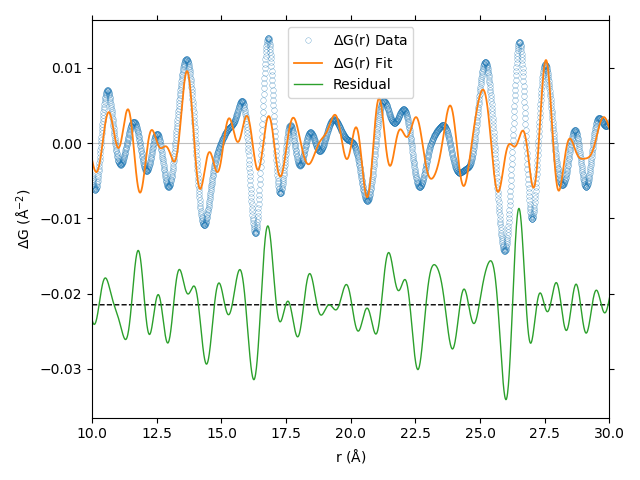

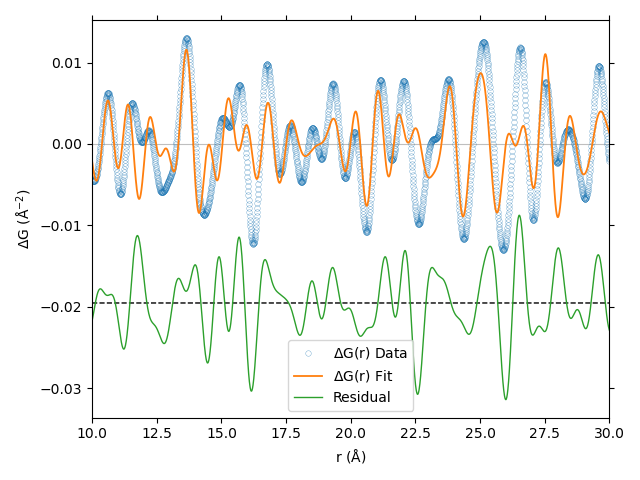

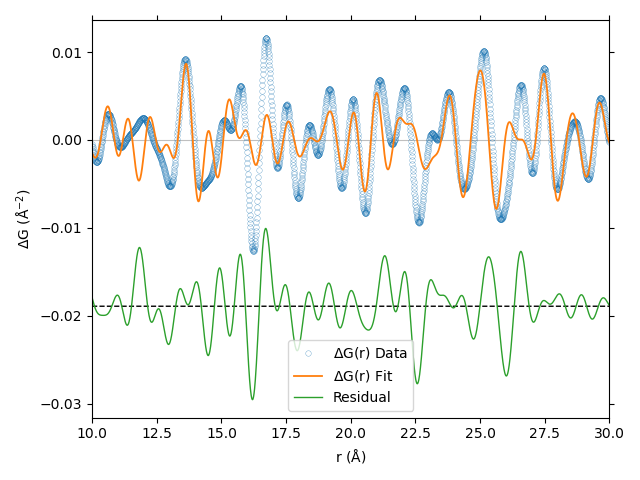

In [6]:
for r in results[:10]:
    r.plot()
    plt.show()

## Fitting with multiple phases

In [9]:
# ── Phase 1: cubic BaTiO3 ────────────────────────────────────────────────────
phase_cubic = PhaseConfig(
    cif_path    = f"{file_path}/BaTiO3_cubic.cif",
    space_group = "Pm-3m",
    name        = "cubic",          # prefix for all params: cubic_a, cubic_s1, …
    scale_i     = 0.3,
    uiso_i      = 0.005,
    delta2_i    = 1.7,
)

# ── Phase 2: tetragonal BaTiO3 ───────────────────────────────────────────────
phase_tet = PhaseConfig(
    cif_path    = f"{file_path}/BaTiO3_tetragonal.cif",
    space_group = "P4mm",
    name        = "tet",            # prefix: tet_a, tet_c, tet_s1, …
    scale_i     = 0.3,
    uiso_i      = 0.005,
    delta2_i    = 1.7,
)

# ── Multi-phase config ────────────────────────────────────────────────────────
cfg_mp = MultiPhaseFitConfig(
    phases = [phase_cubic, phase_tet],

    # ── PDF r-range ───────────────────────────────────────────
    rmin  = 10.0,   # Å
    rmax  = 30.0,   # Å
    rstep = 0.01,   # Å

    # ── Q-range (18 keV) ─────────────────────────────────────
    qmax = 9.0,     # Å⁻¹
    qmin = 0.3,     # Å⁻¹

    # ── Shared instrumental parameters ────────────────────────
    qdamp_i    = 0.01,
    qbroad_i   = 0.008,
    fix_qdamp  = True,
    fix_qbroad = True,

    # ── Parameter bounds (bare names; apply to all phases) ────
    # PhaseConfig.param_bounds overrides these per-phase if needed.
    param_bounds = {
        "s1":           (1e-4, 10.0),
        "Delta2":       (0.0,  50.0),
        "Calib_Qdamp":  (0.0,  0.15),
        "Calib_Qbroad": (0.0,  0.10),
        "a":            (3.9,  4.3),
        "c":            (3.9,  4.3),
        "_adp_default": (1e-5, 0.05),
    },

    # ── Reduced-mode pinning (auto-set from phase names if None) ──
    # pinned_in_reduced = ["cubic_Delta2", "tet_Delta2",
    #                      "Calib_Qdamp", "Calib_Qbroad"],

    # ── Output ───────────────────────────────────────────────
    save_outputs = False,
    run_parallel = True,
)

## Fit One File

Fitting BaTiO3_-80.0_gr.gr [full] — phases: cubic, tet
    scale          Rw = 0.6012
    + lat          Rw = 0.3338
    + adp          Rw = 0.0685
    + Delta2       Rw = 0.0683
    final polish   Rw = 0.0683


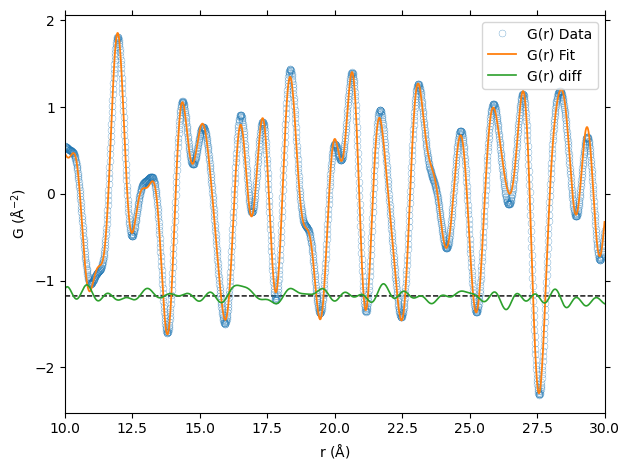

In [10]:
result_mp = fit_one_multiphase(f"{file_path}/BaTiO3_-80.0_gr.gr", cfg_mp)
result_mp.plot()

In [11]:
result_mp.params

{'cubic_s1': np.float64(0.22476883592636768),
 'cubic_a': 4.013848856956053,
 'cubic_ADP_Uiso_0': np.float64(0.016474743099086767),
 'cubic_ADP_Uiso_1': np.float64(0.028966236638890808),
 'cubic_ADP_U11_2': np.float64(0.0498252647834139),
 'cubic_ADP_U22_2': np.float64(0.0445032914323482),
 'cubic_Delta2': 0.030946726847779424,
 'tet_s1': np.float64(0.004369532750491634),
 'tet_a': 3.940513988886866,
 'tet_c': 4.198274111279502,
 'tet_ADP_U11_0': np.float64(1.000004182091992e-05),
 'tet_ADP_U33_0': np.float64(1.0000136184483157e-05),
 'tet_ADP_U11_1': np.float64(2.465768791384372e-05),
 'tet_ADP_U33_1': np.float64(0.04999999988799677),
 'tet_ADP_U11_2': np.float64(1.3038253870287039e-05),
 'tet_ADP_U22_2': np.float64(0.049999999796443276),
 'tet_ADP_U33_2': np.float64(0.049999999958092727),
 'tet_ADP_U11_4': np.float64(0.00012174363816902716),
 'tet_ADP_U33_4': np.float64(4.097264243801754e-05),
 'tet_Delta2': 38.75514348706704,
 'Calib_Qdamp': 0.01,
 'Calib_Qbroad': 0.008}

## Batch Fit

In [ ]:
results_mp = fit_batch_multiphase(f"{file_path}/BaTiO3_*.gr", cfg_mp, full_indices=(1, 2))
df_mp = results_to_dataframe(results_mp)
plot_series(df_mp);

In [ ]:
df_mp